In [1]:
import awkward as ak
import uproot

import matplotlib.pyplot as plt

import uproot

import hist

In [2]:
file_list = [line.strip("\n") + ":events" for line in open("filelists/run2_slimmed_TT.txt")]

In [3]:
f = uproot.concatenate(file_list[0:50])

In [66]:
overallcut= (f.ak4_HT > 500) & (f.jmds6332 < 1.25)
good_ev = f[overallcut]
cut = (good_ev.jtrip_masym < 0.15) & (good_ev.jtrip_mds < 0.175) & (good_ev.jtrip_delta > 250)
mass = ak.flatten(good_ev.jtrip_mass[cut])

AttributeError: 'ReadOnlyDirectory' object has no attribute 'ak4_HT'

In [82]:
h_mass = (
            hist.Hist.new
            .StrCat(["DeltaGr250"], growth=True, name="cuts")
            .Reg(1000, 100, 300, name="mass", label="Trijet Invariant Mass")
            .Weight()
        )

h_mass.fill(mass=mass,cuts="DeltaGr250")

Hist(
  StrCategory(['DeltaGr250'], growth=True, name='cuts'),
  Regular(1000, 100, 300, name='mass', label='Trijet Invariant Mass'),
  storage=Weight()) # Sum: WeightedSum(value=5491, variance=5491) (WeightedSum(value=7185, variance=7185) with flow)

In [83]:
h_mass = h_mass["DeltaGr250",:]

In [84]:
h_mass = h_mass/h_mass.sum().value

In [85]:
f = uproot.open("tight_jet_constraint.root")

In [86]:
hr3 = f["mass/" + "TTbar"].to_hist()['DeltaGr250',:]

In [87]:
hr3 = hr3/hr3.sum().value

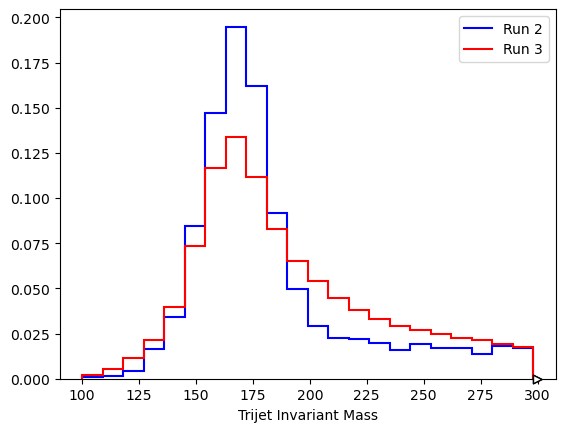

In [91]:
h_mass[::45j].plot(color="blue",histtype="step",yerr=False,label="Run 2")
hr3[::45j].plot(color="red",histtype="step",yerr=False,label="Run 3")
plt.legend()